In regression  we could try to fit non-linearities in the data by exploiting nonlinear functions, for example polynomials, Gaussian kernels and sigmoidal functions. Respectively,
$$\phi_j(x) = x^j, \quad \phi_j(x) \exp\left( - \frac{(x-\mu_j)^2}{2s^2} \right), \quad \phi_j(x) = \sigma\left( \frac{x-\mu}{s} \right)$$
where $\sigma(a) = 1/(1+e^{-a})$.

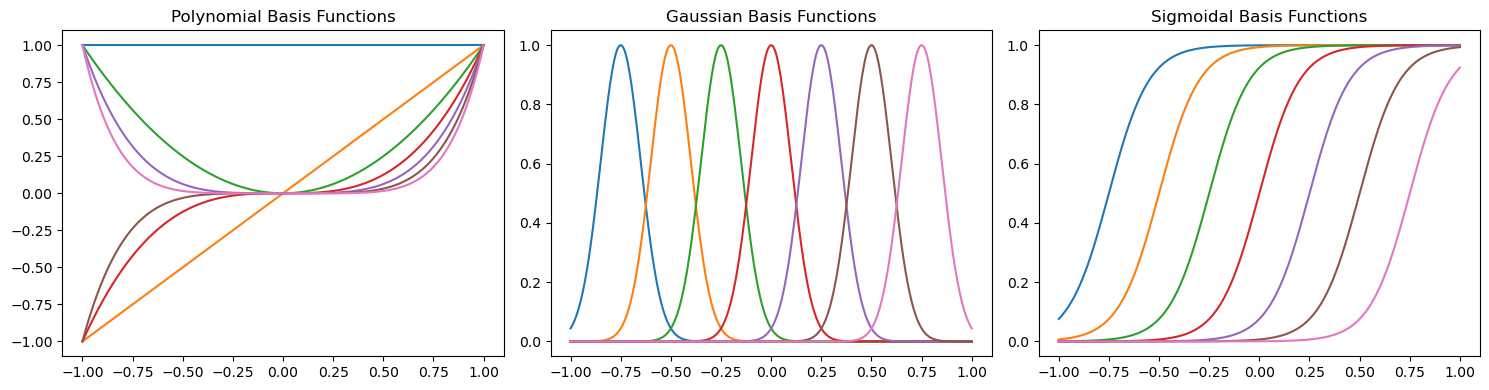

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-1, 1, 400)

# Polynomial basis functions (up to degree 3)
poly_basis = [x**i for i in range(7)]

# Gaussian basis functions
mu_gauss = [-0.75,-0.5, -0.25, 0, 0.25, 0.5, 0.75]
s_gauss = 0.1
gaussian_basis = [np.exp(-(x - mu)**2 / (2 * s_gauss**2)) for mu in mu_gauss]

# Sigmoidal basis functions
mu_sigmoid = [-0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75]
s_sigmoid = 0.1
sigmoid_basis = [1 / (1 + np.exp(-(x - mu) / s_sigmoid)) for mu in mu_sigmoid]

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Plot polynomial basis
axs[0].set_title("Polynomial Basis Functions")
for i, f in enumerate(poly_basis):
    axs[0].plot(x, f, label=f"x^{i}")

# Plot Gaussian basis
axs[1].set_title("Gaussian Basis Functions")
for i, f in enumerate(gaussian_basis):
    axs[1].plot(x, f, label=f"μ={mu_gauss[i]}")

# Plot Sigmoidal basis
axs[2].set_title("Sigmoidal Basis Functions")
for i, f in enumerate(sigmoid_basis):
    axs[2].plot(x, f, label=f"μ={mu_sigmoid[i]}")

# Final layout
plt.tight_layout()
plt.show()


We can achieve different level of regularization by modifying the exponent of the penalty. In particular, by modifying $q$ in
$$ \frac{1}{2} \sum_{n=1}^N [t_n - \mathbf{w}^\top \phi(\mathbf{x}_n)]^2 + \frac{\lambda}{2} \sum_{j=1}^M \vert w_j \vert^q $$
Note that for $q = 2$ we get the Ridge penalty and for $q= 1$ the Lasso penalty.

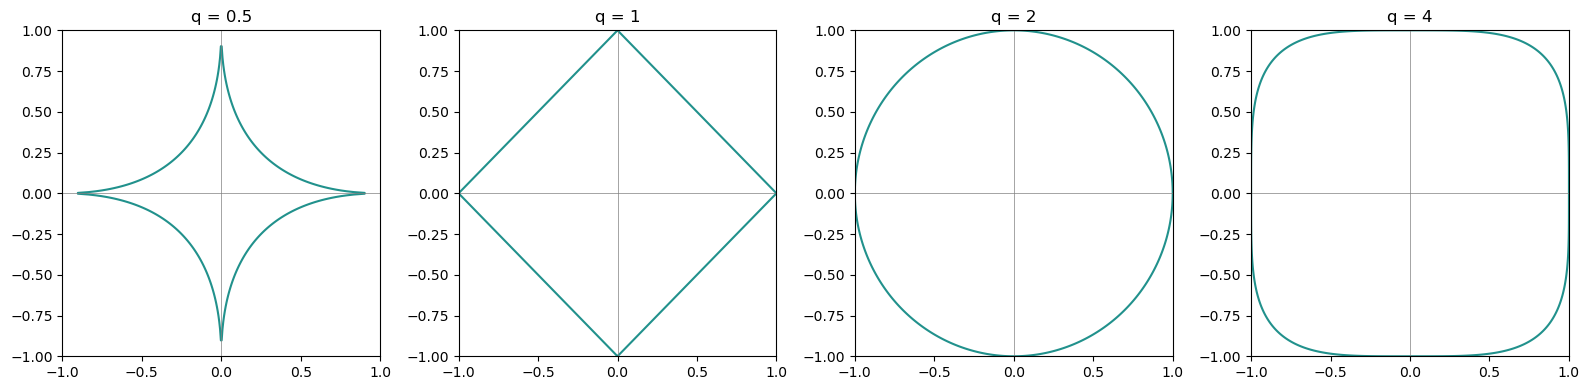

In [3]:
# Create a grid of (w1, w2) values
w1 = np.linspace(-1, 1, 400)
w2 = np.linspace(-1, 1, 400)
W1, W2 = np.meshgrid(w1, w2)

# Regularization values for different q
q_values = [0.5, 1, 2, 4]
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

for i, q in enumerate(q_values):
    R = np.abs(W1)**q + np.abs(W2)**q  # Regularization term
    ax = axs[i]
    CS = ax.contour(W1, W2, R, levels=1)
    ax.set_title(f"q = {q}")
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()


We illustrate the dependence of bias and variance on model complexity, governed by a regularization parameter $\lambda$, using the sinusoidal data (from Chapter 1). There are $L = 100$ data sets, each having $N = 25$ data points, and there are 24 Gaussian basis functions in the model so that the total number of parameters is $M = 25$ including the bias parameter (intercept).

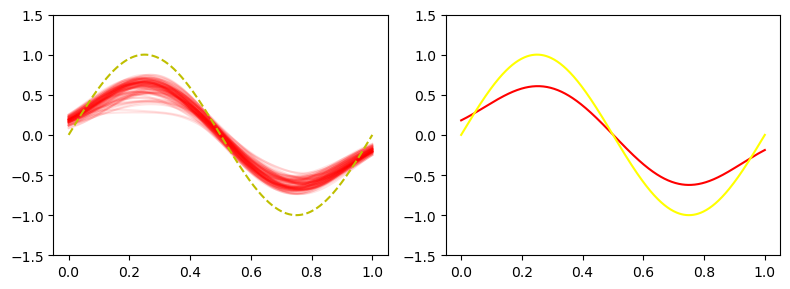

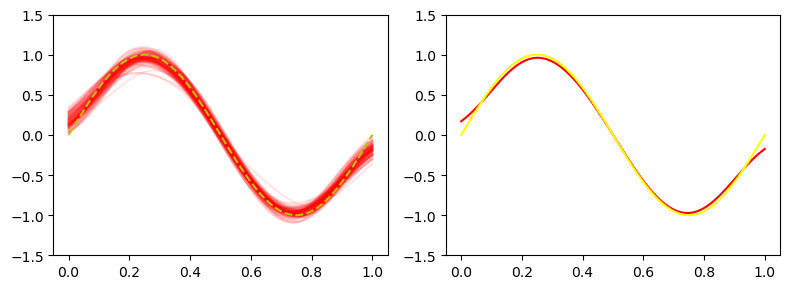

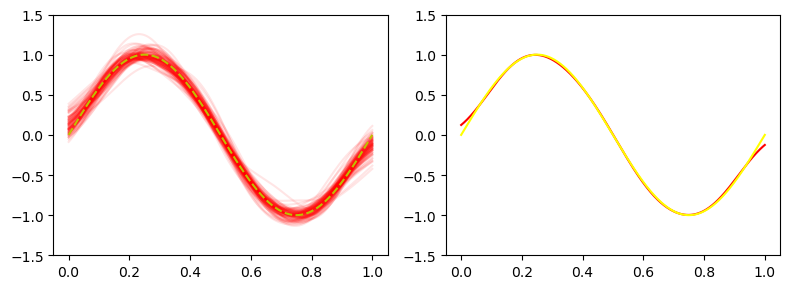

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(0)

# Parameters
L = 100        # number of datasets
N = 25         # number of data points per dataset
M = 24         # number of Gaussian basis functions
x_plot = np.linspace(0, 1, 500)
centers = np.linspace(0, 1, M)
s = 0.1        # width of Gaussian basis functions
true_func = lambda x: np.sin(2 * np.pi * x)

# Define Gaussian basis functions
def design_matrix(x):
    return np.exp(-0.5 * ((x[:, None] - centers[None, :]) / s) ** 2)

# Generate datasets
datasets = []
for _ in range(L):
    x = np.random.uniform(0, 1, N)
    t = true_func(x) + np.random.normal(0, 0.1, size=N)  # noise
    datasets.append((x, t))

# Function to fit model and return predictions
def fit_and_predict(x_train, t_train, x_test, lam):
    Phi = design_matrix(x_train)
    Phi_test = design_matrix(x_test)
    # Regularized weights (ridge regression)
    w = np.linalg.solve(Phi.T @ Phi + lam * np.eye(M), Phi.T @ t_train)
    return Phi_test @ w

# Plotting function for a given lambda
def plot_results(lam):
    plt.figure(figsize=(8, 3))

    # Left: multiple fits
    plt.subplot(1, 2, 1)
    for x_train, t_train in datasets:
        y_pred = fit_and_predict(x_train, t_train, x_plot, lam)
        plt.plot(x_plot, y_pred, color='red', alpha=0.1)
    plt.plot(x_plot, true_func(x_plot), 'y--')
    plt.ylim(-1.5, 1.5)

    # Right: average prediction vs true function
    avg_preds = np.zeros_like(x_plot)
    for x_train, t_train in datasets:
        avg_preds += fit_and_predict(x_train, t_train, x_plot, lam)
    avg_preds /= L

    plt.subplot(1, 2, 2)
    plt.plot(x_plot, avg_preds, 'r')
    plt.plot(x_plot, true_func(x_plot), 'yellow')
    plt.ylim(-1.5, 1.5)

    plt.tight_layout()
    plt.show()

# Plot results for high and low regularization
plot_results(lam=np.exp(2.6))
plot_results(lam=np.exp(-0.31))
plot_results(lam=np.exp(-2.4))


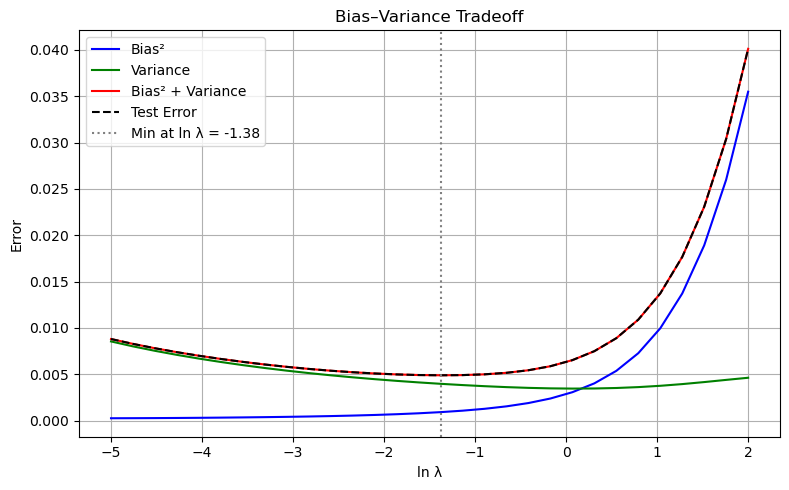

In [22]:
# Generate datasets
datasets = []
for _ in range(L):
    x_train = np.random.uniform(0, 1, N)
    t_train = true_func(x_train) + np.random.normal(0, 0.1, N)
    datasets.append((x_train, t_train))

# Evaluation grid
x_eval = np.linspace(0, 1, 1000)
Phi_eval = design_matrix(x_eval)
h_x = true_func(x_eval)

# Lambda range (in log scale)
log_lambdas = np.linspace(-5, 2, 30)
lambdas = np.exp(log_lambdas)

# Store results
bias2_list = []
var_list = []
mse_list = []

# Main loop over lambda
for lam in lambdas:
    preds = []
    for x_train, t_train in datasets:
        Phi_train = design_matrix(x_train)
        w = np.linalg.solve(Phi_train.T @ Phi_train + lam * np.eye(M), Phi_train.T @ t_train)
        y_pred = Phi_eval @ w
        preds.append(y_pred)
    
    preds = np.array(preds)  # Shape (L, len(x_eval))

    # Bias^2
    mean_pred = np.mean(preds, axis=0)
    bias2 = np.mean((mean_pred - h_x)**2)

    # Variance
    variance = np.mean(np.var(preds, axis=0))

    # MSE (average test error)
    mse = np.mean((preds - h_x[None, :])**2)

    bias2_list.append(bias2)
    var_list.append(variance)
    mse_list.append(mse)

# Convert to arrays
bias2_list = np.array(bias2_list)
var_list = np.array(var_list)
mse_list = np.array(mse_list)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(log_lambdas, bias2_list, label='Bias²', color='blue')
plt.plot(log_lambdas, var_list, label='Variance', color='green')
plt.plot(log_lambdas, bias2_list + var_list, label='Bias² + Variance', color='red')
plt.plot(log_lambdas, mse_list, label='Test Error', color='black', linestyle='--')

# Mark minimum of bias² + variance
min_index = np.argmin(bias2_list + var_list)
optimal_log_lambda = log_lambdas[min_index]
plt.axvline(optimal_log_lambda, color='gray', linestyle=':', label=f"Min at ln λ = {optimal_log_lambda:.2f}")

plt.xlabel("ln λ")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Next we consider again the Gaussian-Gaussian model we studied previously, where the posterior distribution is given by $\mathbf{w} \mid \Phi, \mathbf{t},\alpha,\beta \sim \mathcal{N}(\mathbf{m}_N, \mathbf{S}_N)$, where $\mathbf{S}_N^{-1} = \alpha \mathbf{I} + \beta \Phi^\top \Phi$ and $\mathbf{m}_N = \beta \mathbf{S}_N \Phi^\top \mathbf{t}$. Here $\Phi$ has the role of the (previous) $\mathbf{X}$ and contains the regressors, appropriately transformed according to the chosen basis function (polynomial, sigmoidal, etc.).

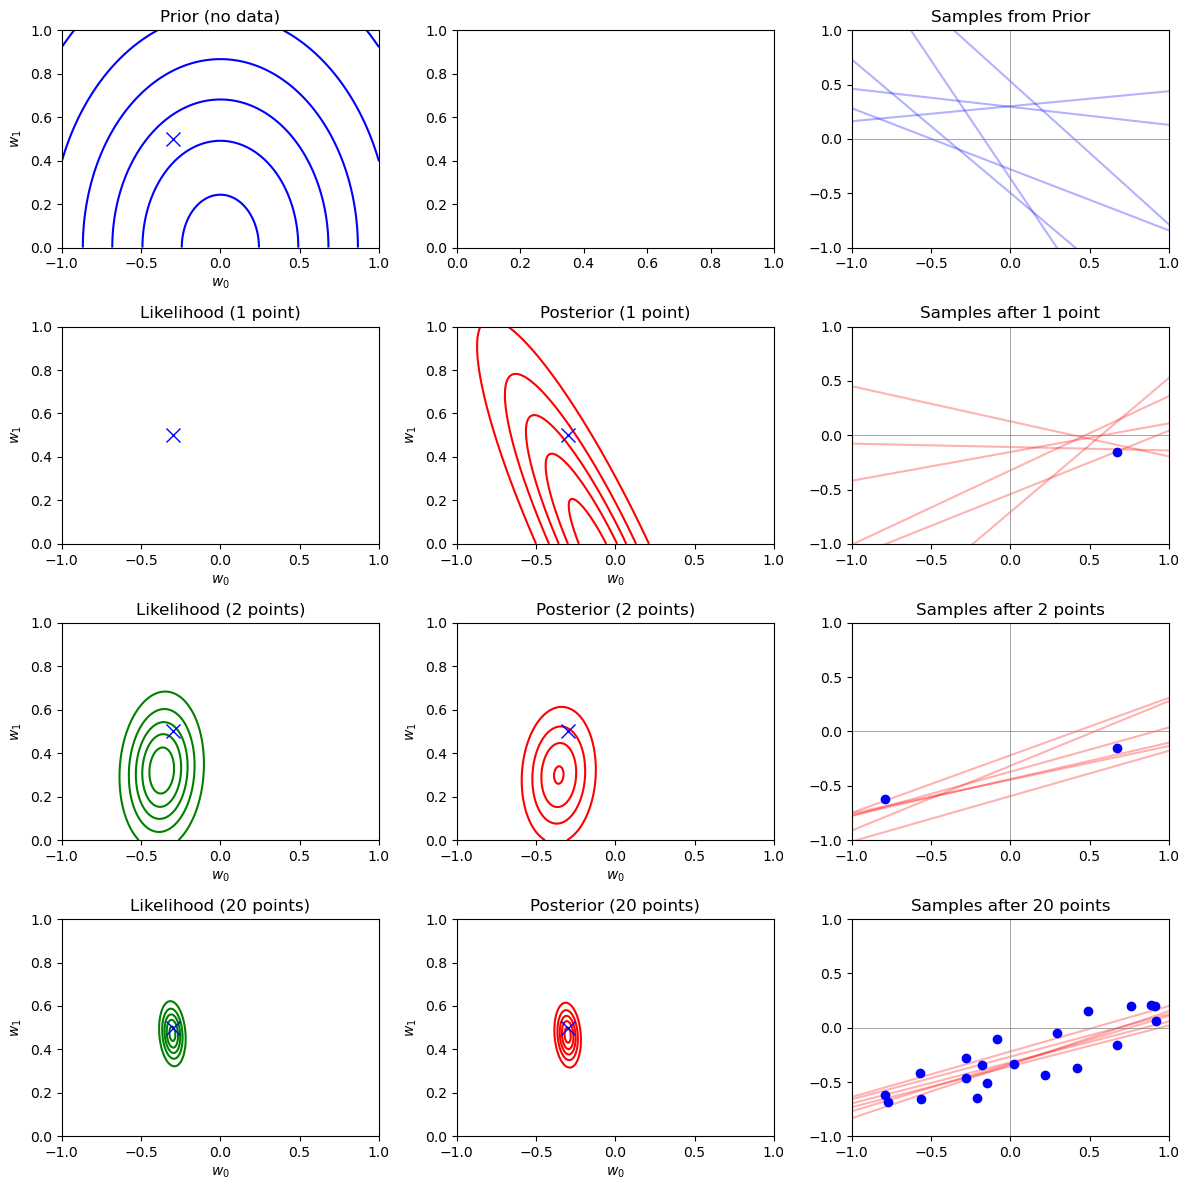

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Settings
np.random.seed(44)
alpha = 2.0  # Prior precision
beta = 25.0  # Noise precision (1 / noise_variance)
noise_std = 0.2
true_w = np.array([-0.3, 0.5])

# Generate data
def generate_data(n=20):
    x = np.random.uniform(-1, 1, n)
    t = true_w[0] + true_w[1] * x + np.random.normal(0, noise_std, size=n)
    return x, t

# Design matrix for linear model
def design_matrix(x):
    return np.vstack((np.ones_like(x), x)).T  # shape (N, 2)

# Bayesian update equations
def posterior(Phi, t, alpha, beta):
    S_inv = alpha * np.eye(2) + beta * Phi.T @ Phi
    S = np.linalg.inv(S_inv)
    m = beta * S @ Phi.T @ t
    return m, S

# Plot contour in w-space
def plot_contour(ax, mean, cov, label, color='blue'):
    w0 = np.linspace(-1.0, 1.0, 200)
    w1 = np.linspace(0.0, 1.0, 200)
    W0, W1 = np.meshgrid(w0, w1)
    pos = np.dstack((W0, W1))
    
    # Allow singular matrices (e.g., with 1 data point)
    rv = multivariate_normal(mean=mean, cov=cov, allow_singular=True)
    
    Z = rv.pdf(pos)
    ax.contour(W0, W1, Z, levels=5, colors=color)
    ax.plot(true_w[0], true_w[1], 'bx', markersize=10)
    ax.set_xlabel('$w_0$')
    ax.set_ylabel('$w_1$')
    ax.set_title(label)

# Sample functions from posterior
def plot_sample_functions(ax, weights, color, label=None):
    x_plot = np.linspace(-1, 1, 100)
    for w in weights:
        y = w[0] + w[1] * x_plot
        ax.plot(x_plot, y, color=color, alpha=0.3)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_title(label)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

# Prepare figure
fig, axs = plt.subplots(4, 3, figsize=(12, 12))
x_all, t_all = generate_data(20)

# Prior
prior_mean = np.zeros(2)
prior_cov = np.eye(2) / alpha
plot_contour(axs[0, 0], prior_mean, prior_cov, 'Prior (no data)', 'blue')
w_samples = np.random.multivariate_normal(prior_mean, prior_cov, 6)
plot_sample_functions(axs[0, 2], w_samples, 'blue', 'Samples from Prior')

# 1 data point
Phi1 = design_matrix(x_all[:1])
t1 = t_all[:1]
like_mean = Phi1.T @ t1
like_cov = np.linalg.inv(beta * Phi1.T @ Phi1)
plot_contour(axs[1, 0], like_mean.flatten(), like_cov, 'Likelihood (1 point)', 'green')

post1_mean, post1_cov = posterior(Phi1, t1, alpha, beta)
plot_contour(axs[1, 1], post1_mean, post1_cov, 'Posterior (1 point)', 'red')
w_samples = np.random.multivariate_normal(post1_mean, post1_cov, 6)
axs[1, 2].scatter(x_all[:1], t_all[:1], c='blue', zorder=5)
plot_sample_functions(axs[1, 2], w_samples, 'red', 'Samples after 1 point')

# 2 data points
Phi2 = design_matrix(x_all[:2])
t2 = t_all[:2]
like_mean2 = np.linalg.pinv(Phi2) @ t2
like_cov2 = np.linalg.inv(beta * Phi2.T @ Phi2)
plot_contour(axs[2, 0], like_mean2, like_cov2, 'Likelihood (2 points)', 'green')

post2_mean, post2_cov = posterior(Phi2, t2, alpha, beta)
plot_contour(axs[2, 1], post2_mean, post2_cov, 'Posterior (2 points)', 'red')
w_samples = np.random.multivariate_normal(post2_mean, post2_cov, 6)
axs[2, 2].scatter(x_all[:2], t_all[:2], c='blue', zorder=5)
plot_sample_functions(axs[2, 2], w_samples, 'red', 'Samples after 2 points')

# 20 data points
Phi20 = design_matrix(x_all)
t20 = t_all
like_mean20 = np.linalg.pinv(Phi20) @ t20
like_cov20 = np.linalg.inv(beta * Phi20.T @ Phi20)
plot_contour(axs[3, 0], like_mean20, like_cov20, 'Likelihood (20 points)', 'green')

post20_mean, post20_cov = posterior(Phi20, t20, alpha, beta)
plot_contour(axs[3, 1], post20_mean, post20_cov, 'Posterior (20 points)', 'red')
w_samples = np.random.multivariate_normal(post20_mean, post20_cov, 6)
axs[3, 2].scatter(x_all, t_all, c='blue', zorder=5)
plot_sample_functions(axs[3, 2], w_samples, 'red', 'Samples after 20 points')

plt.tight_layout()
plt.show()


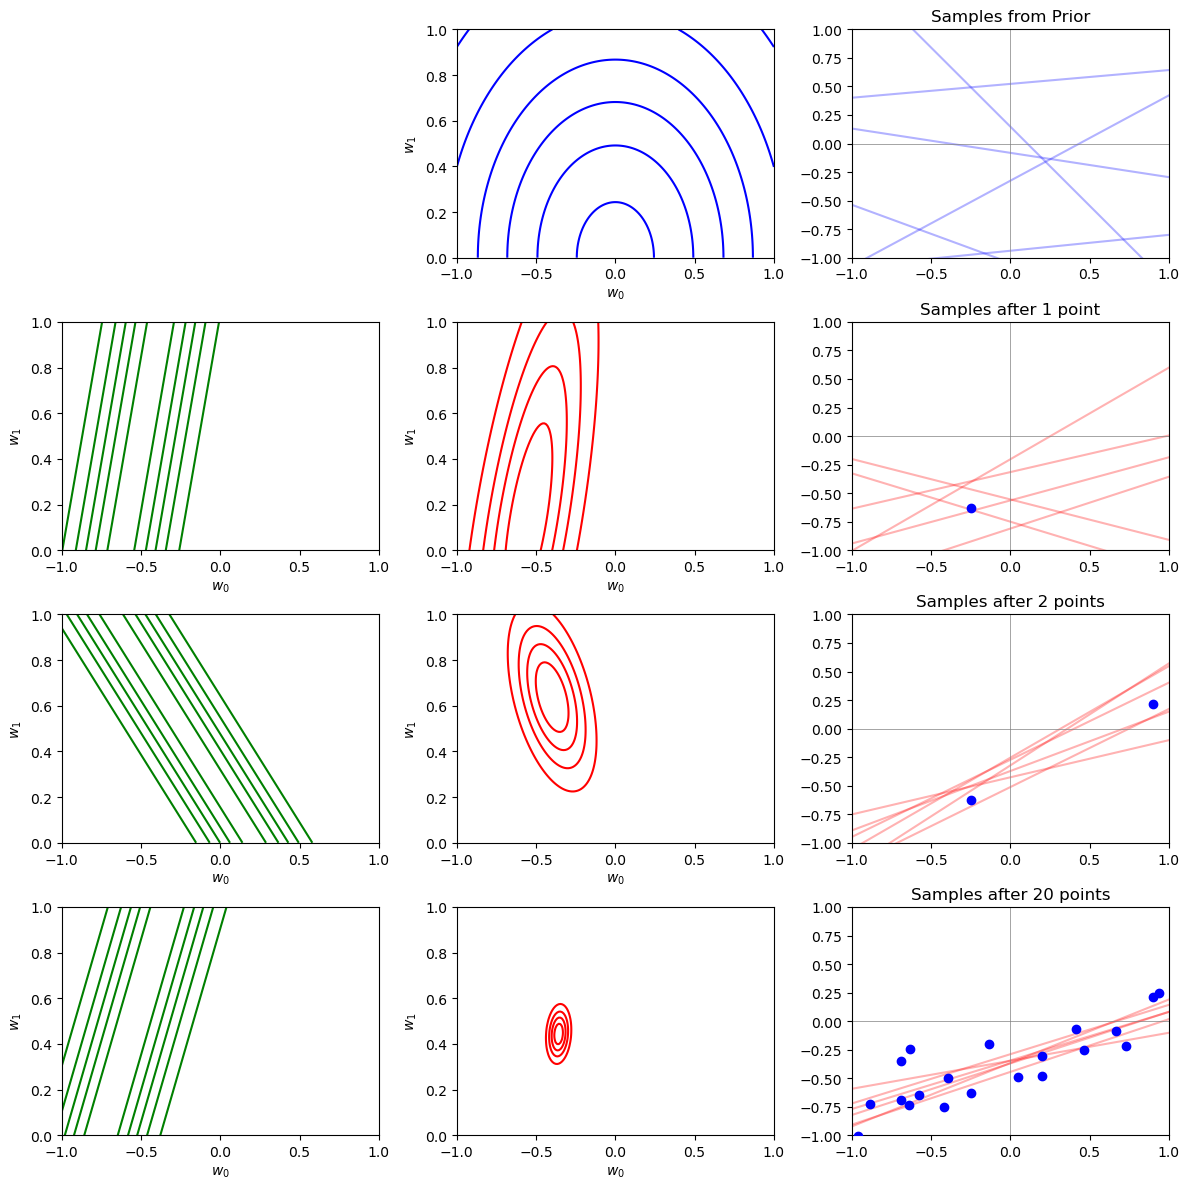

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Settings
np.random.seed(42)
alpha = 2.0           # Prior precision
beta = 25.0           # Noise precision
noise_std = 0.2
true_w = np.array([-0.3, 0.5])
eps = 1e-6            # Jitter for numerical stability

# Generate synthetic data
def generate_data(n=20):
    x = np.random.uniform(-1, 1, n)
    t = true_w[0] + true_w[1] * x + np.random.normal(0, noise_std, size=n)
    return x, t

# Design matrix for linear model y = w0 + w1*x
def design_matrix(x):
    return np.vstack((np.ones_like(x), x)).T  # shape (N, 2)

# Posterior update for Bayesian linear regression
def posterior(Phi, t, alpha, beta):
    S_inv = alpha * np.eye(2) + beta * Phi.T @ Phi
    S = np.linalg.inv(S_inv)
    m = beta * S @ Phi.T @ t
    return m, S

# Plot contour in w-space
def plot_contour(ax, mean, cov, label, color='blue'):
    w0 = np.linspace(-1.0, 1.0, 200)
    w1 = np.linspace(0.0, 1.0, 200)
    W0, W1 = np.meshgrid(w0, w1)
    pos = np.dstack((W0, W1))
    
    rv = multivariate_normal(mean=mean, cov=cov, allow_singular=True)
    Z = rv.pdf(pos)
    ax.contour(W0, W1, Z, levels=5, colors=color)
    ax.set_xlabel('$w_0$')
    ax.set_ylabel('$w_1$')

# Plot function samples
def plot_sample_functions(ax, weights, color, label=None):
    x_plot = np.linspace(-1, 1, 100)
    for w in weights:
        y = w[0] + w[1] * x_plot
        ax.plot(x_plot, y, color=color, alpha=0.3)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_title(label)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

# Generate full dataset
x_all, t_all = generate_data(20)

# Prepare figure
fig, axs = plt.subplots(4, 3, figsize=(12, 12))

# ---------- Row 1: Prior only ----------
prior_mean = np.zeros(2)
prior_cov = np.eye(2) / alpha

# No likelihood — blank plot
axs[0, 0].axis('off')  

# Prior contour
plot_contour(axs[0, 1], prior_mean, prior_cov, 'Prior (0 points)', 'blue')

# Samples from prior
w_samples = np.random.multivariate_normal(prior_mean, prior_cov, 6)
plot_sample_functions(axs[0, 2], w_samples, 'blue', 'Samples from Prior')

# ---------- Row 2: After 1 data point ----------
Phi1 = design_matrix(x_all[:1])
t1 = t_all[:1]

# Likelihood from 1st point only
like_cov1 = np.linalg.inv(beta * Phi1.T @ Phi1 + eps * np.eye(2))
like_mean1 = beta * like_cov1 @ Phi1.T @ t1
plot_contour(axs[1, 0], like_mean1.flatten(), like_cov1, 'Likelihood (1st point)', 'green')

# Posterior after 1 point
post1_mean, post1_cov = posterior(Phi1, t1, alpha, beta)
plot_contour(axs[1, 1], post1_mean, post1_cov, 'Posterior (1 point)', 'red')

# Function samples after 1 point
axs[1, 2].scatter(x_all[:1], t_all[:1], c='blue', zorder=5)
w_samples = np.random.multivariate_normal(post1_mean, post1_cov, 6)
plot_sample_functions(axs[1, 2], w_samples, 'red', 'Samples after 1 point')

# ---------- Row 3: After 2 data points ----------
# Likelihood from 2nd point only
Phi2only = design_matrix(x_all[1:2])
t2only = t_all[1:2]
like_cov2 = np.linalg.inv(beta * Phi2only.T @ Phi2only + eps * np.eye(2))
like_mean2 = beta * like_cov2 @ Phi2only.T @ t2only
plot_contour(axs[2, 0], like_mean2.flatten(), like_cov2, 'Likelihood (2nd point)', 'green')

# Posterior after 2 points
Phi2 = design_matrix(x_all[:2])
t2 = t_all[:2]
post2_mean, post2_cov = posterior(Phi2, t2, alpha, beta)
plot_contour(axs[2, 1], post2_mean, post2_cov, 'Posterior (2 points)', 'red')

# Function samples after 2 points
axs[2, 2].scatter(x_all[:2], t_all[:2], c='blue', zorder=5)
w_samples = np.random.multivariate_normal(post2_mean, post2_cov, 6)
plot_sample_functions(axs[2, 2], w_samples, 'red', 'Samples after 2 points')

# ---------- Row 4: After 20 data points ----------
# Likelihood from 20th point only
Phi20only = design_matrix(x_all[19:20])
t20only = t_all[19:20]
like_cov20 = np.linalg.inv(beta * Phi20only.T @ Phi20only + eps * np.eye(2))
like_mean20 = beta * like_cov20 @ Phi20only.T @ t20only
plot_contour(axs[3, 0], like_mean20.flatten(), like_cov20, 'Likelihood (20th point)', 'green')

# Posterior after all 20 points
Phi20 = design_matrix(x_all)
t20 = t_all
post20_mean, post20_cov = posterior(Phi20, t20, alpha, beta)
plot_contour(axs[3, 1], post20_mean, post20_cov, 'Posterior (20 points)', 'red')

# Function samples after 20 points
axs[3, 2].scatter(x_all, t_all, c='blue', zorder=5)
w_samples = np.random.multivariate_normal(post20_mean, post20_cov, 6)
plot_sample_functions(axs[3, 2], w_samples, 'red', 'Samples after 20 points')

plt.tight_layout()
plt.show()


Similarly, we consider the predictive distribution of the previous model, which we found to be $t \mid x, \mathbf{x}, \mathbf{t} \sim \mathcal{N}(m(x),s^2(x))$, where
$$ m(x) = \phi(x)^\top \mathbf{m}_N = \phi(x)^\top \beta \mathbf{S}_N \mathbf{X}^\top \mathbf{t} = \beta \phi(x)^\top \mathbf{S}_N \sum_{n=1}^N \phi(x_n) t_n $$
and
$$ s^2(x) = \mathbb{V}[\phi(x)^\top \mathbf{w}\mid \mathbf{x},\mathbf{t}] + \mathbb{V}[t|\mathbf{x},\mathbf{w},\beta] = \phi(x)^\top \mathbf{S}_N \phi(x) + \beta^{-1} $$

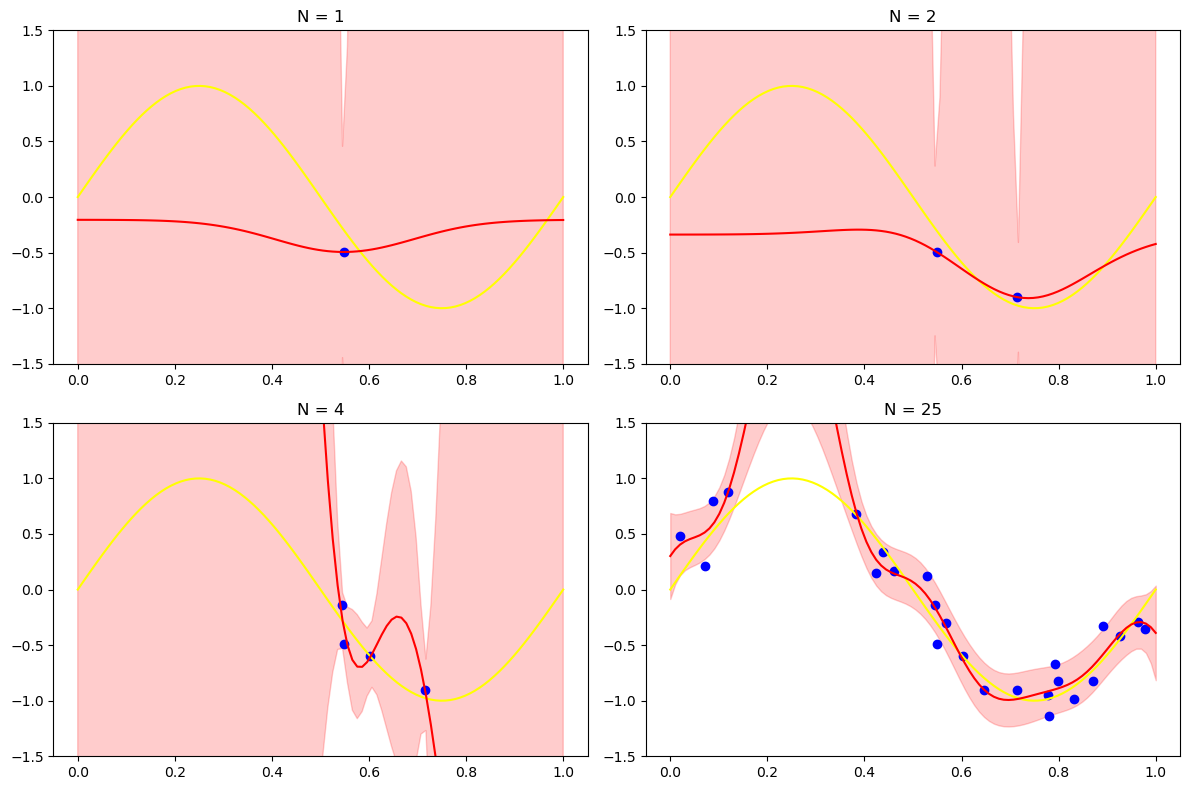

In [41]:
# True function
def true_function(x):
    return np.sin(2 * np.pi * x)

# Gaussian basis functions
def gaussian_basis(x, centers, s):
    return np.exp(-0.5 * ((x[:, None] - centers[None, :]) / s) ** 2)

# Design matrix with bias term
def design_matrix(x, centers, s):
    Phi = gaussian_basis(x, centers, s)
    return np.column_stack((np.ones(Phi.shape[0]), Phi))  # Add bias

# Posterior predictive mean and variance
def posterior_predictive(Phi_train, t_train, Phi_test, alpha, beta):
    S_N_inv = alpha * np.eye(Phi_train.shape[1]) + beta * Phi_train.T @ Phi_train
    S_N = np.linalg.inv(S_N_inv)
    m_N = beta * S_N @ Phi_train.T @ t_train
    mean = Phi_test @ m_N
    var = 1 / beta + np.sum(Phi_test @ S_N * Phi_test, axis=1)
    return mean, var

# Hyperparameters
alpha = 1e-3
beta = 1 / (0.2 ** 2)
s = 0.1
centers = np.linspace(0, 1, 9)  # 9 Gaussian basis functions

# Generate data
np.random.seed(0)
x_full = np.linspace(0, 1, 100)
y_true = true_function(x_full)

x_data = np.random.rand(25)
t_data = true_function(x_data) + np.random.normal(0, 0.2, size=x_data.shape)
data_sizes = [1, 2, 4, 25]

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, N in enumerate(data_sizes):
    x_n = x_data[:N]
    t_n = t_data[:N]

    Phi_train = design_matrix(x_n, centers, s)
    Phi_test = design_matrix(x_full, centers, s)

    mean, var = posterior_predictive(Phi_train, t_n, Phi_test, alpha, beta)
    std = np.sqrt(var)

    ax = axs[i]
    ax.plot(x_full, y_true, 'yellow')
    ax.plot(x_full, mean, 'red')
    ax.fill_between(x_full, mean - std, mean + std, color='r', alpha=0.2,)
    ax.scatter(x_n, t_n, c='blue')
    ax.set_title(f'N = {N}')
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()


The model evidence is obtained by marginalizing our model of interest with respect to the (estimated) parameters, in our case $\mathbf{w}$,
$$ p(\mathbf{t} \mid \alpha, \beta) = \int  p(\mathbf{t}\mid \mathbf{w}, \beta)p(\mathbf{w}\mid\alpha)\, d\mathbf{w} $$
Taking the logarithm does not change the final result (as it is a monotonic transformation),
$$ \ln p(\mathbf{t}\mid \alpha, \beta) = \frac{M}{2} \ln \alpha + \frac{N}{2} \ln \beta - E(\mathbf{m}_N) - \frac{1}{2}\ln \vert \mathbf{S}_N^{-1}\vert - \frac{N}{2}\ln 2\pi $$

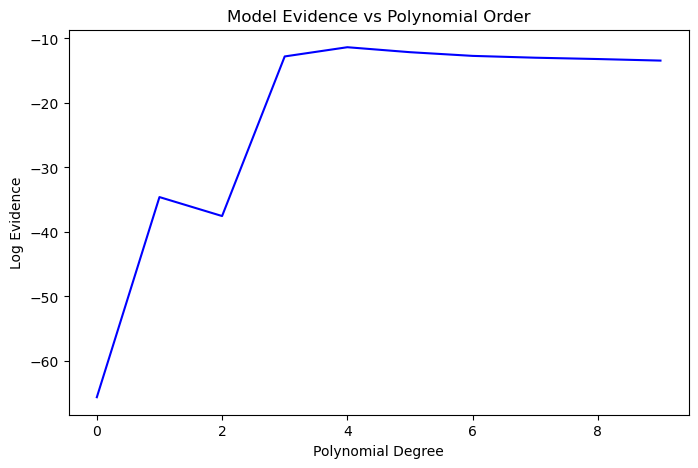

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import slogdet, inv

# Generate synthetic data
np.random.seed(84)
N = 25
x = np.linspace(0, 1, N)
t = np.sin(2 * np.pi * x) + np.random.normal(0, 0.1, size=N)

# Hyperparameters
alpha = 5e-3
beta = 1 / (0.3 ** 2)  # noise precision

# Design matrix for polynomial of degree M
def design_matrix(x, M):
    return np.vstack([x**i for i in range(M + 1)]).T

# Log marginal likelihood
def log_marginal_likelihood(Phi, t, alpha, beta):
    N, M = Phi.shape
    A = alpha * np.eye(M) + beta * Phi.T @ Phi
    m_N = beta * inv(A) @ Phi.T @ t
    Ed = 0.5 * beta * np.sum((t - Phi @ m_N)**2)
    Ew = 0.5 * alpha * np.sum(m_N**2)
    E_mN = Ed + Ew
    sign, logdet_A = slogdet(A)
    logML = (M / 2) * np.log(alpha) + (N / 2) * np.log(beta) - E_mN - 0.5 * logdet_A - (N / 2) * np.log(2 * np.pi)
    return logML

# Evaluate for different model complexities
max_degree = 9
log_evidences = []
degrees = list(range(0, max_degree + 1))

for M in degrees:
    Phi = design_matrix(x, M)
    logML = log_marginal_likelihood(Phi, t, alpha, beta)
    log_evidences.append(logML)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(degrees, log_evidences, color = "blue")
plt.title('Model Evidence vs Polynomial Order')
plt.xlabel('Polynomial Degree')
plt.ylabel('Log Evidence')
plt.show()
